In [ ]:
!unzip PlantVillage.zip

Archive:  PlantVillage.zip
   creating: PlantVillage/
  inflating: __MACOSX/._PlantVillage  
   creating: PlantVillage/Potato___Early_blight/
  inflating: __MACOSX/PlantVillage/._Potato___Early_blight  
  inflating: PlantVillage/.DS_Store  
  inflating: __MACOSX/PlantVillage/._.DS_Store  
   creating: PlantVillage/Potato___Late_blight/
  inflating: __MACOSX/PlantVillage/._Potato___Late_blight  
   creating: PlantVillage/Potato___healthy/
  inflating: __MACOSX/PlantVillage/._Potato___healthy  
  inflating: PlantVillage/Potato___Early_blight/acb84d77-5b1c-4beb-be27-99fee467bf1f___RS_Early.B 7577.JPG  
  inflating: __MACOSX/PlantVillage/Potato___Early_blight/._acb84d77-5b1c-4beb-be27-99fee467bf1f___RS_Early.B 7577.JPG  
  inflating: PlantVillage/Potato___Early_blight/bc7552e4-3901-41b8-8bef-727eeca4270e___RS_Early.B 7942.JPG  
  inflating: __MACOSX/PlantVillage/Potato___Early_blight/._bc7552e4-3901-41b8-8bef-727eeca4270e___RS_Early.B 7942.JPG  
  inflating: PlantVillage/Potato___Early_bli

In [ ]:
class_names = !ls PlantVillage
class_names

['Potato___Early_blight  Potato___healthy  Potato___Late_blight']

In [ ]:
DATASET_PATH = "PlantVillage"

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 32

In [ ]:
df = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH, #directory
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [ ]:
classes = df.class_names
classes

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
len(df)

68

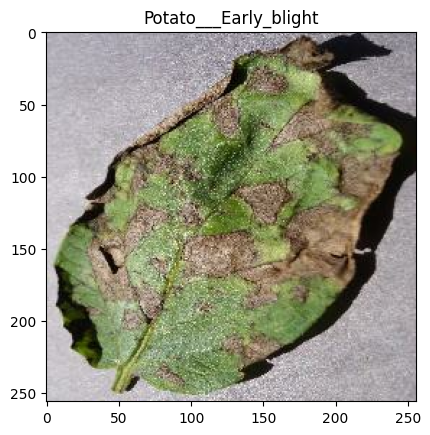

In [ ]:
for image_batch, label_batch in df.take(1):
  plt.title(classes[label_batch[0]])
  plt.imshow(image_batch[0].numpy().astype('uint8'))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
len(df)*0.8

54.400000000000006

In [ ]:
train_df = df.take(54)
test_df = df.skip(54)
val_df = test_df.take(6)
test_df = test_df.skip(6)

In [ ]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
  ds_size = len(ds)

  if shuffle:
    ds = df.shuffle(shuffle_size, seed=12)

  train_size = int(train_split*ds_size)
  val_size = int(val_split*ds_size)

  train_ds = ds.take(train_size)

  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)

  return train_ds, val_ds, test_ds

train_df, val_df, test_df = get_dataset_partitions_tf(df)

In [ ]:
len(train_df)

54

In [ ]:
resized_rescaled = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1./255)
])

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

Model Building

In [ ]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, 3)
model = models.Sequential([
    resized_rescaled,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
])
model.build(input_shape=input_shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 5)                │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,877 (718.27 KB)

 Trainable params: 183,877 (718.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [ ]:
history =model.fit(
    train_df,
    batch_size = BATCH_SIZE,
    validation_data = val_df,
    verbose = 1,
    epochs = 15
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 254s 5s/step - accuracy: 0.9277 - loss: 0.1936 - val_accuracy: 0.9115 - val_loss: 0.2335
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 258s 5s/step - accuracy: 0.9262 - loss: 0.1988 - val_accuracy: 0.9219 - val_loss: 0.1965
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.9163 - loss: 0.2063 - val_accuracy: 0.9271 - val_loss: 0.1873
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.9414 - loss: 0.1629 - val_accuracy: 0.9635 - val_loss: 0.0948
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.9340 - loss: 0.1687 - val_accuracy: 0.9323 - val_loss: 0.1779
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 260s 5s/step - accuracy: 0.9415 - loss: 0.1650 - val_accuracy: 0.9167 - val_loss: 0.2030
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.9433 - loss: 0.1472 - val_accuracy: 0.9010 - val_loss: 0.2428
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.9390 - loss: 0.1903 - val_accuracy: 0.9531 - v

In [ ]:
score = model.evaluate(test_df)
score

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8845 - loss: 0.2938


[0.3093796670436859, 0.87890625]

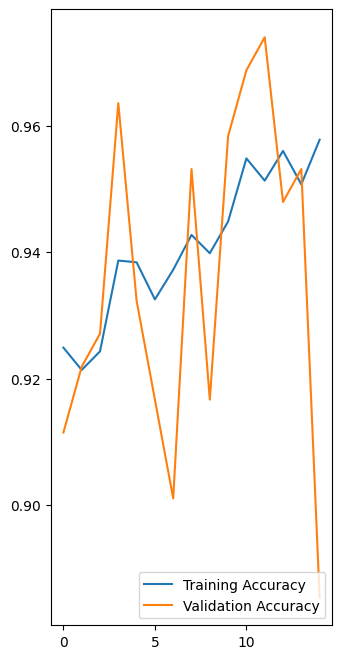

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(15), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(15), history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')

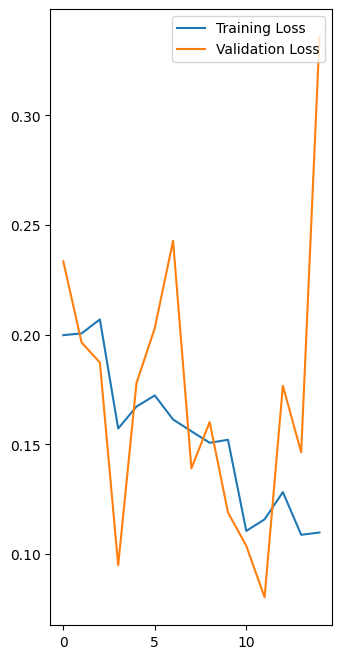

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(15), history.history['loss'], label='Training Loss')
plt.plot(range(15), history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted label: Potato___Early_blight


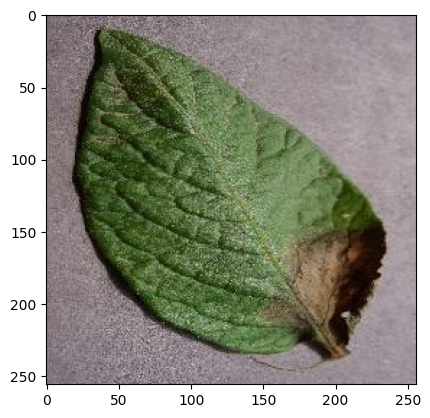

In [ ]:
import numpy as np
for image_batch, label_batch in test_df.take(1):
  first_image = image_batch[10].numpy().astype('uint8')
  first_label = label_batch[10].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:", classes[first_label])

  batch_prediction = model.predict(image_batch)
  print("predicted label:", classes[np.argmax(batch_prediction[0])])


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

IMAGE_SIZE = 256   # same as training

class_names = [
    'Potato___Early_blight',
    'Potato___Healthy',
    'Potato___Late_blight'
]

# load trained model
#model = tf.keras.models.load_model("potato_model.h5")

# load image
img = image.load_img("/content/images (1).jpeg", target_size=(IMAGE_SIZE, IMAGE_SIZE))
img = image.img_to_array(img)
img = tf.expand_dims(img, axis=0)
img = img / 255.0   # same rescaling

# predict
pred = model.predict(img)
idx = np.argmax(pred[0])

print("Prediction:", class_names[idx])
print("Confidence:", round(pred[0][idx]*100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction: Potato___Early_blight
Confidence: 57.35 %
